In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import math
import os

In [3]:
os.chdir('/Users/cherylxiang/Documents/GitHub/demultiplexing-methods/')
print(os.getcwd())

/Users/cherylxiang/Documents/GitHub/demultiplexing-methods


In [4]:
#get all summary csvs
summary_files = glob.glob('results/**/**/summary.csv', recursive=True)
summary_files = list(set(summary_files))

print(summary_files)

['results/demuxmixnaive/howitt_cell_cap3/summary.csv', 'results/bffraw/cook_mix1/summary.csv', 'results/hashsolo/winkler_pdx1a/summary.csv', 'results/demultiplex2/gaublomme/summary.csv', 'results/bffraw/bar18/summary.csv', 'results/demuxmixnaive/howitt_cell_cap2/summary.csv', 'results/hasheddrops/howitt_b1c1/summary.csv', 'results/bffraw/howitt_b2c2/summary.csv', 'results/htodemux/winkler_pdx3b/summary.csv', 'results/demuxmixnaive/howitt_b1c2/summary.csv', 'results/demultiplex/gaublomme/summary.csv', 'results/htodemux/howitt_cell_cap1/summary.csv', 'results/htodemux/mcginnis_hto/summary.csv', 'results/gmmdemux/howitt_cell_cap3/summary.csv', 'results/demultiplex/bar20/summary.csv', 'results/demuxmixnaive/bar18/summary.csv', 'results/bffcluster/mcginnis_ms/summary.csv', 'results/demuxmixnaive/mcginnis_hto/summary.csv', 'results/demultiplex/winkler_pdx3b/summary.csv', 'results/htodemux/bar18/summary.csv', 'results/bffraw/cook_mix4a/summary.csv', 'results/hasheddrops/stoeckius/summary.csv'

In [5]:
#read and combine
all_results = pd.concat([pd.read_csv(f) for f in summary_files], ignore_index=True)

#save combined dataframe
all_results.to_csv('results/all_results.csv', index=False)

all_results

,classification,n,dataset,method
0,doublet,1432,howitt_cell_cap3,demuxmix_naive
1,negative,5065,howitt_cell_cap3,demuxmix_naive
2,singlet,8275,howitt_cell_cap3,demuxmix_naive
3,total,14772,howitt_cell_cap3,demuxmix_naive
4,doublet,42,cook_mix1,bff_raw
...,...,...,...,...
891,total,11431,bar18,hasheddrops
892,doublet,2036,cook_mix3b,demultiplex
893,negative,824,cook_mix3b,demultiplex
894,singlet,8524,cook_mix3b,demultiplex


In [6]:
plot_data = all_results[all_results['classification'] != 'total'].copy()
methods = sorted(plot_data['method'].unique())

In [7]:
dataset_order = [
    'ah1',
    'gaublomme',
    'mcginnis_hto',
    'mcginnis_ms',
    'stoeckius',
    'cook_mix1',
    'cook_mix2',
    'cook_mix3a',
    'cook_mix3b',
    'howitt_cell_cap1',
    'howitt_cell_cap2',
    'howitt_cell_cap2',
    'howitt_b1c1',
    'howitt_b1c2',
    'howitt_b2c1',
    'howitt_b2c2',
    'howitt_b3c1',
    'howitt_b3c2',
    'winkler_pdx1a',
    'winkler_pdx1b',
    'winkler_pdx1c',
    'winkler_pdx1d',
    'winkler_pdx3a',
    'winkler_pdx3b',
    'bar18',
    'bar20'
]

method_order = [
    'demultiplex',
    'demultiplex2',
    'gmmdemux',
    'htodemux',
    'hashsolo',
    'hasheddrops',
    'bff_raw',
    'bff_cluster',
    'demuxmix',
    'demuxmix_naive',
    'demuxem'
]

In [9]:
colors = {
    'singlet':  "#446fac", 
    'doublet':  "#5E5E5E", 
    'negative': "#CACACA"
}

method_labels = {
    'demultiplex': 'Demultiplex',
    'demultiplex2': 'Demultiplex2',
    'htodemux': 'HTODemux',
    'hashsolo': 'HashSolo',
    'hasheddrops': 'HashedDrops',
    'bff_raw': 'BFF_Raw',
    'bff_cluster': 'BFF_Cluster',
    'gmmdemux': 'GMMDemux',
    'demuxmix': 'DemuxMix',
    'demuxmix_naive': 'DemuxMix Naive',
    'cmddemux': 'CMDdemux',
    'demuxem' : 'DemuxEM'
}

dataset_labels = {
    'ah1' : 'Ji_Bar11',
    'gaublomme': 'Gaublomme',
    'mcginnis_hto': 'McGinnis_HTO',
    'mcginnis_ms': 'McGinnis_MS',
    'stoeckius': 'Stoeckius',
    'cook_mix1' : 'Cook_Mix1',
    'cook_mix2' : 'Cook_Mix2',
    'cook_mix3a' : 'Cook_Mix3a',
    'cook_mix3b' : 'Cook_Mix3b',
    'cook_mix4a' : 'Cook_Mix4a',
    'cook_mix4b' : 'Cook_Mix4b',
    'howitt_cell_cap1' : 'Howitt_Cap1',
    'howitt_cell_cap2' : 'Howitt_Cap2',
    'howitt_cell_cap3' : 'Howitt_Cap3',
    'howitt_b1c1' : 'Howitt_Batch1_C1',
    'howitt_b1c2' : 'Howitt_Batch1_C2',
    'howitt_b2c1' : 'Howitt_Batch2_C1',
    'howitt_b2c2' : 'Howitt_Batch2_C2',
    'howitt_b3c1' : 'Howitt_Batch3_C1',
    'howitt_b3c2' : 'Howitt_Batch3_C2',
    'winkler_pdx1a': 'Winkler_PDX1a',
    'winkler_pdx1b': 'Winkler_PDX1b',
    'winkler_pdx1c': 'Winkler_PDX1c',
    'winkler_pdx1d': 'Winkler_PDX1d',
    'winkler_pdx3a': 'Winkler_PDX3a',
    'winkler_pdx3b': 'Winkler_PDX3b',
    'bar18' : 'Bar18',
    'bar20' : 'Bar20'
}



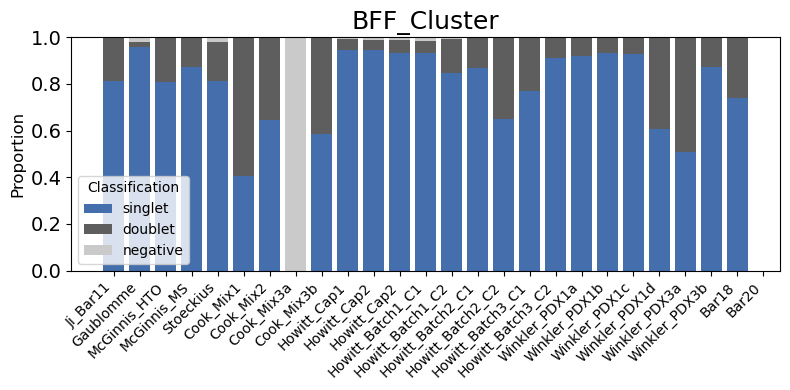

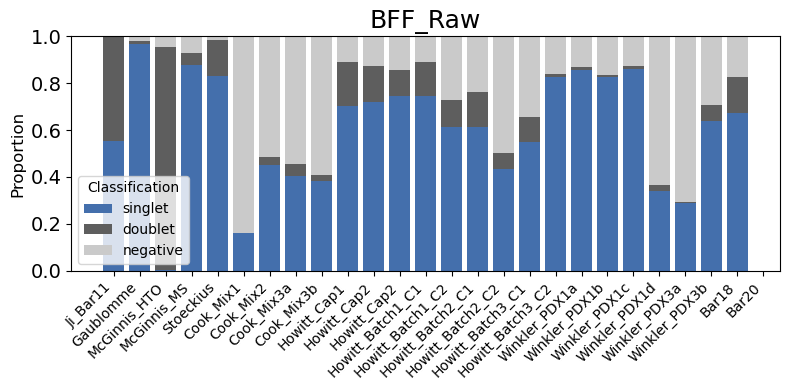

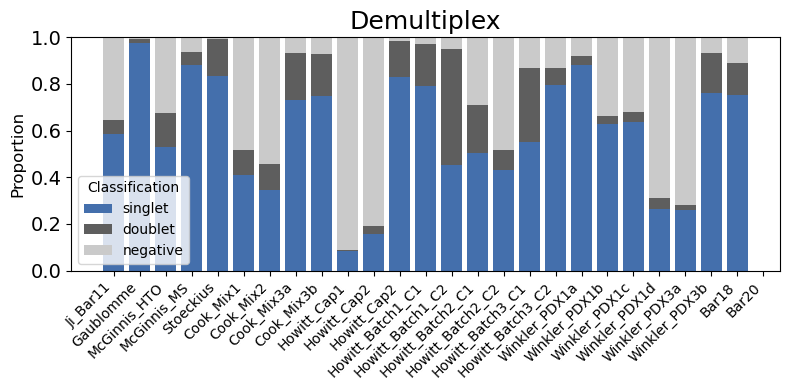

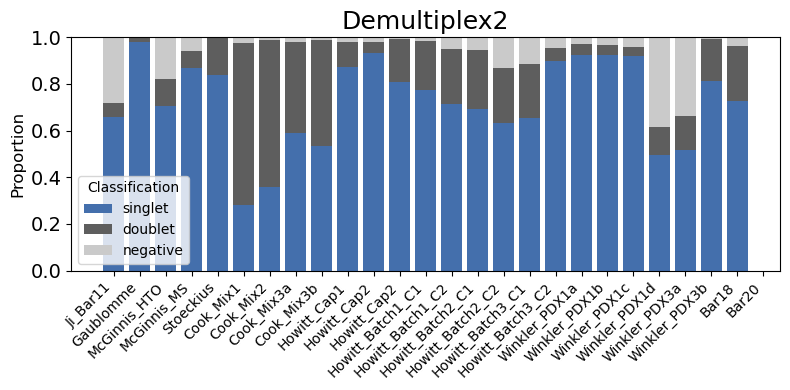

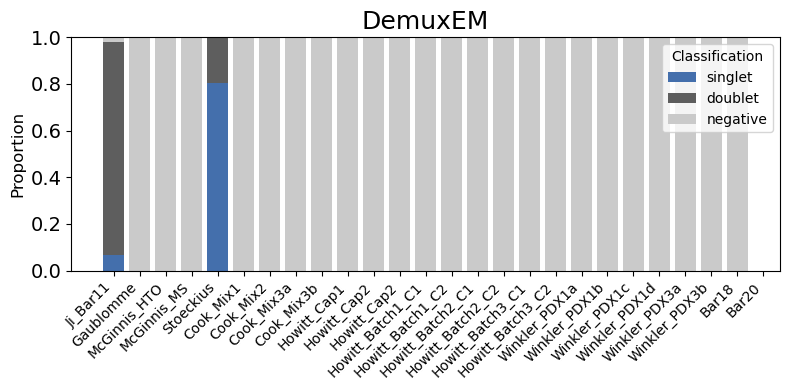

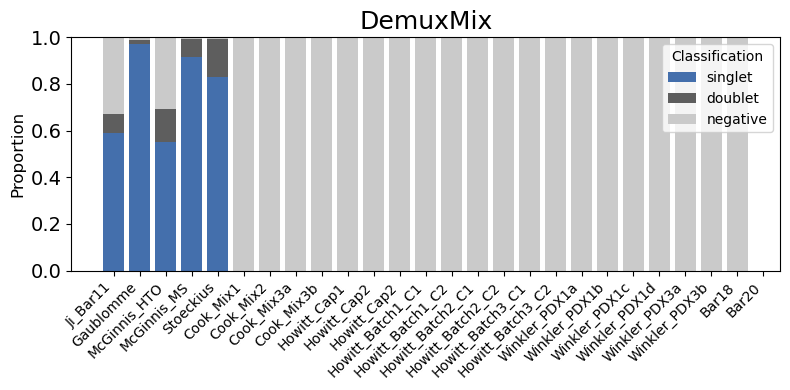

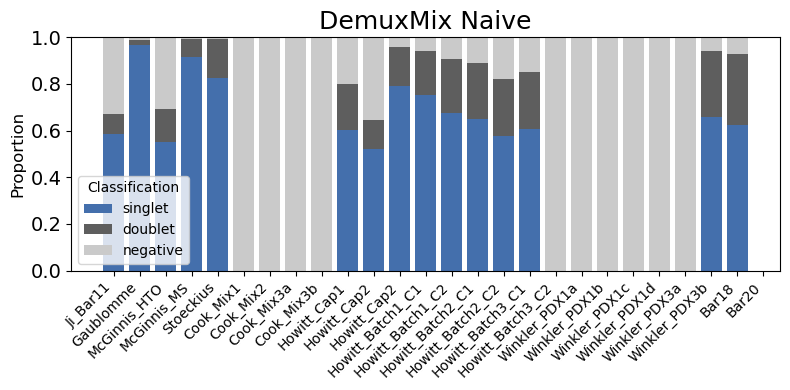

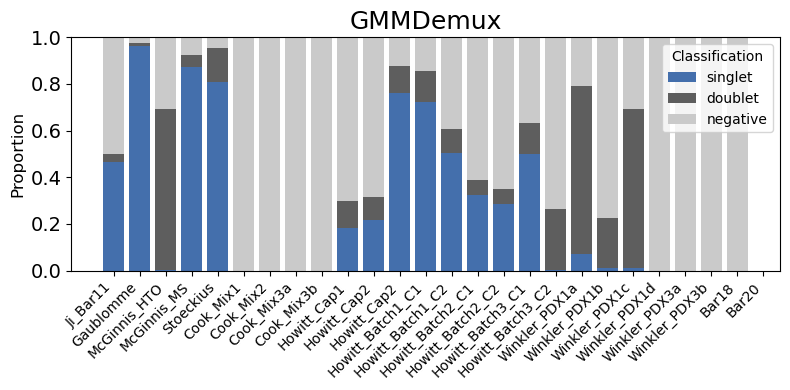

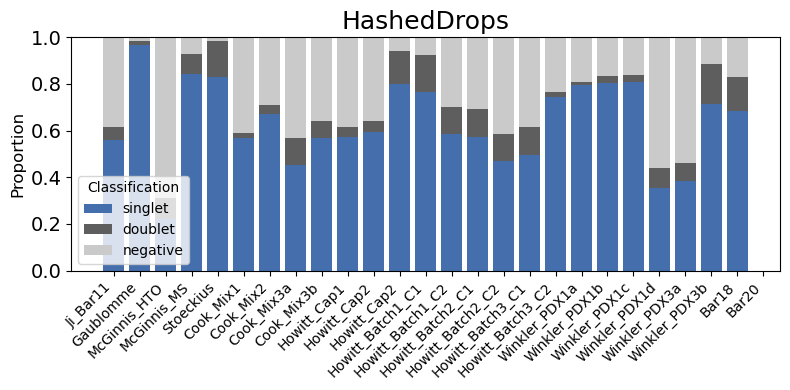

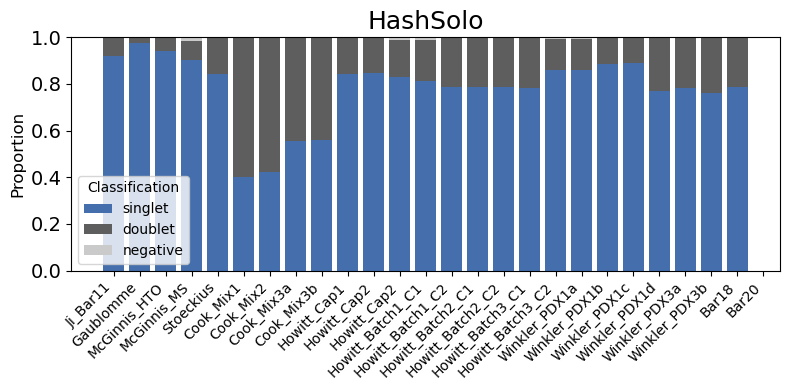

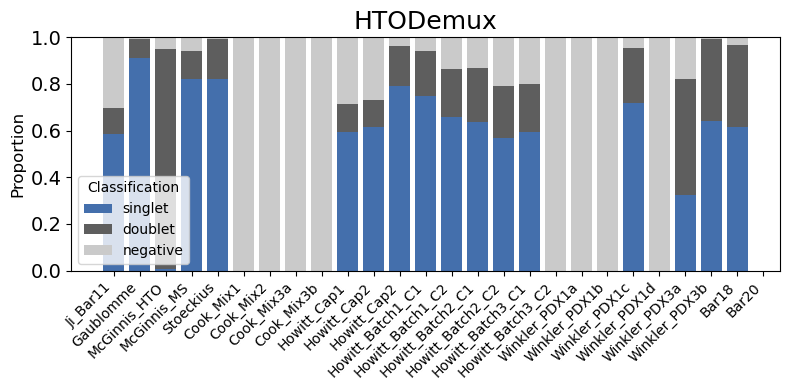

In [16]:
for method in methods:
    method_data = plot_data[plot_data['method'] == method].copy()
    method_data['proportion'] = method_data.groupby('dataset')['n'].transform(lambda x: x / x.sum())

    pivot = method_data.pivot_table(
        index='dataset',
        columns='classification',
        values='proportion',
        fill_value=0
    )

    # add missing datasets as all negative
    for dataset in dataset_order:
        if dataset not in pivot.index:
            pivot.loc[dataset] = 0
            if 'negative' in pivot.columns:
                pivot.loc[dataset, 'negative'] = 1.0
            else:
                pivot['negative'] = 0
                pivot.loc[dataset, 'negative'] = 1.0

    # apply custom dataset order
    ordered_datasets = [d for d in dataset_order if d in pivot.index]
    pivot = pivot.loc[ordered_datasets]

    col_order = [c for c in ['singlet', 'doublet', 'negative'] if c in pivot.columns]
    pivot = pivot[col_order]

    fig, ax = plt.subplots(figsize=(8, 4))
    bottom = pd.Series([0] * len(pivot), index=pivot.index)

    for classification in col_order:
        ax.bar(pivot.index, pivot[classification],
               bottom=bottom,
               label=classification,
               color=colors[classification])
        bottom += pivot[classification]

    ax.set_ylabel('Proportion', fontsize=12)
    ax.set_title(method_labels.get(method, method), fontsize=18)
    ax.set_ylim(0, 1)
    ax.legend(title='Classification')
    ax.set_xticks(range(len(pivot.index)))
    ax.set_xticklabels([dataset_labels.get(d, d) for d in pivot.index], rotation=45, ha='right', fontsize=10)
    plt.yticks(fontsize=14)
    plt.tight_layout()

    os.makedirs(f'analysis/figures/{method}', exist_ok=True)
    plt.savefig(f'analysis/figures/{method}/stacked_bar.pdf')
    plt.show()

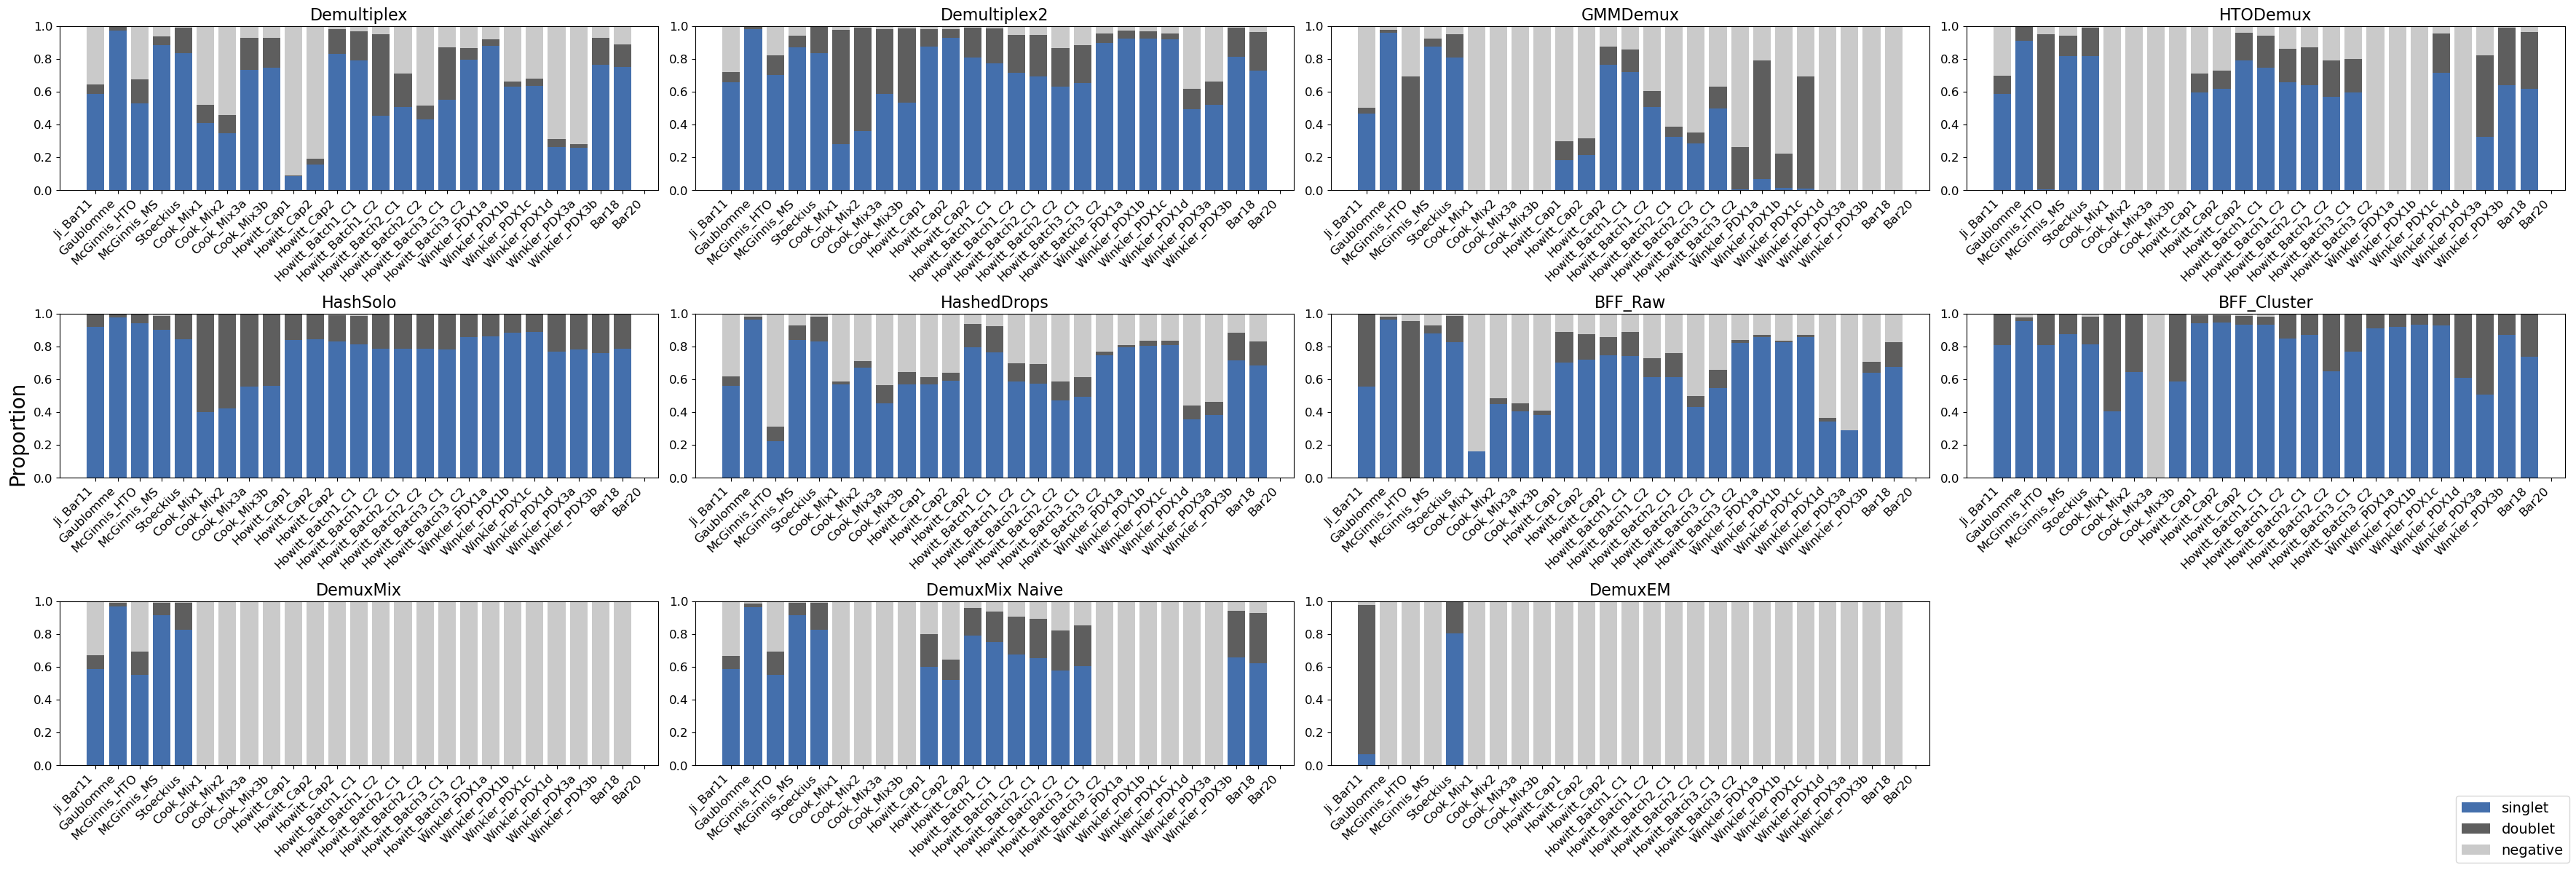

In [24]:
n_methods = len(method_order)
n_cols = 4
n_rows = math.ceil(n_methods / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 9, n_rows * 4))
axes = axes.flatten()

for i, method in enumerate(method_order):
    ax = axes[i]
    method_data = plot_data[plot_data['method'] == method].copy()
    method_data['proportion'] = method_data.groupby('dataset')['n'].transform(lambda x: x / x.sum())

    pivot = method_data.pivot_table(
        index='dataset',
        columns='classification',
        values='proportion',
        fill_value=0
    )

    # add missing datasets as all negative
    for dataset in dataset_order:
        if dataset not in pivot.index:
            pivot.loc[dataset] = 0
            if 'negative' in pivot.columns:
                pivot.loc[dataset, 'negative'] = 1.0
            else:
                pivot['negative'] = 0
                pivot.loc[dataset, 'negative'] = 1.0

    ordered_datasets = [d for d in dataset_order if d in pivot.index]
    pivot = pivot.loc[ordered_datasets]

    col_order = [c for c in ['singlet', 'doublet', 'negative'] if c in pivot.columns]
    pivot = pivot[col_order]

    bottom = pd.Series([0] * len(pivot), index=pivot.index)
    for classification in col_order:
        ax.bar(pivot.index, pivot[classification],
               bottom=bottom,
               label=classification,
               color=colors[classification])
        bottom += pivot[classification]

    ax.set_title(method_labels.get(method, method), fontsize=16)
    ax.set_ylim(0, 1)
    ax.set_xticks(range(len(pivot.index)))
    ax.set_xticklabels([dataset_labels.get(d, d) for d in pivot.index], rotation=45, ha='right', fontsize=12)
    ax.tick_params(axis='y', labelsize=12)

# hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# single shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower right', fontsize=14)
fig.supylabel('Proportion', fontsize=20)

plt.tight_layout()
plt.subplots_adjust(left=0.04)
os.makedirs('analysis/figures', exist_ok=True)
plt.savefig('analysis/figures/all_methods.pdf')
plt.show()